<a href="https://www.kaggle.com/code/jfaisal/groupj-aiml505-soilmoisture-gnn-notebook?scriptVersionId=340846146" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# AIML505 Course Project — Group J 
**Soil Moisture Forecasting and Smart Irrigation Decision Support**

**Track B: Graph based models**

**Team:** Jobayer Faisal Fahim (2026-2-74-014) · Md. Rafiqul Islam (2026-2-74-025) 

**Dataset:** [Bhopal AgriTech Hybrid IoT Dataset for Predictive Irrigation (Kaggle)](https://www.kaggle.com/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation)


In [1]:
import torch
TORCH_VERSION = torch.__version__.split("+")[0]
CUDA_VERSION = "cu" + torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"
print(f"Torch: {TORCH_VERSION}  CUDA tag: {CUDA_VERSION}")

wheel_url = f"https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html"
!pip install torch-scatter torch-sparse torch-cluster -f {wheel_url} -q

!pip install torch_geometric torch_geometric_temporal -q

Torch: 2.10.0  CUDA tag: cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 868.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mne 1.12.1 requires decorator>=5.1, but you have decorator 4.4.2 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 41,691 | Columns: 13


,Timestamp,Soil_Moisture,Temperature,Humidity,Hour,Hour_sin,Hour_cos,irrigation_status,soil_moisture_next_1m,Soil_Moisture_scaled,soil_moisture_next_1m_scaled,Temperature_scaled,Humidity_scaled
0,2026-03-21 21:45:00,28.183161,16.171837,92.013366,21,-0.707107,0.707107,0,27.149938,0.299840,0.271012,0.000000,0.995206
1,2026-03-21 21:46:00,27.149938,16.218045,91.947128,21,-0.707107,0.707107,0,27.449942,0.228319,0.275615,0.075135,0.994426
2,2026-03-21 21:47:00,27.449942,16.110563,91.813688,21,-0.707107,0.707107,0,27.360247,0.226708,0.274239,0.000000,0.992854
3,2026-03-21 21:48:00,27.360247,16.308547,91.864382,21,-0.707107,0.707107,0,26.693737,0.225146,0.264012,0.018790,0.993451
4,2026-03-21 21:49:00,26.693737,16.226439,91.623486,21,-0.707107,0.707107,0,27.465866,0.303284,0.275860,0.000000,0.990614


## Setup & Data Understanding

In [3]:
print(df.dtypes)
print()
print(df.columns.tolist())

Timestamp                       datetime64[ns]
Soil_Moisture                          float64
Temperature                            float64
Humidity                               float64
Hour                                     int64
Hour_sin                               float64
Hour_cos                               float64
irrigation_status                        int64
soil_moisture_next_1m                  float64
Soil_Moisture_scaled                   float64
soil_moisture_next_1m_scaled           float64
Temperature_scaled                     float64
Humidity_scaled                        float64
dtype: object

['Timestamp', 'Soil_Moisture', 'Temperature', 'Humidity', 'Hour', 'Hour_sin', 'Hour_cos', 'irrigation_status', 'soil_moisture_next_1m', 'Soil_Moisture_scaled', 'soil_moisture_next_1m_scaled', 'Temperature_scaled', 'Humidity_scaled']


In [4]:
print(f"Start: {df['Timestamp'].min()}")
print(f"End:   {df['Timestamp'].max()}")
print(f"Total span: {df['Timestamp'].max() - df['Timestamp'].min()}")

diffs = df["Timestamp"].diff().dropna()
print("\nTop timestamp intervals:")
print(diffs.value_counts().head())

modal_interval = diffs.mode()[0]
gaps = diffs[diffs > modal_interval * 2]
print(f"\nGaps larger than 2x modal interval: {len(gaps)}")

Start: 2026-03-21 21:45:00
End:   2026-04-19 20:35:00
Total span: 28 days 22:50:00

Top timestamp intervals:
Timestamp
0 days 00:01:00    41690
Name: count, dtype: int64

Gaps larger than 2x modal interval: 0


In [5]:
raw_features = ["Soil_Moisture", "Temperature", "Humidity"]
time_features = ["Hour", "Hour_sin", "Hour_cos"]
control_feature = "irrigation_status"
target_col = "soil_moisture_next_1m"
scaled_features = ["Soil_Moisture_scaled", "Temperature_scaled", "Humidity_scaled", "soil_moisture_next_1m_scaled"]

print("Missing values:", df.isna().sum().sum())
print()
print(df[target_col].describe())
print()
print(df[control_feature].value_counts())
print(df[control_feature].value_counts(normalize=True).round(4))

Missing values: 0

count    41691.000000
mean        28.861621
std         10.414116
min          9.488551
25%         21.607334
50%         26.978859
75%         35.357760
max         74.656851
Name: soil_moisture_next_1m, dtype: float64

irrigation_status
0    41681
1       10
Name: count, dtype: int64
irrigation_status
0    0.9998
1    0.0002
Name: proportion, dtype: float64


In [6]:
for raw_col, scaled_col in [
    ("Soil_Moisture", "Soil_Moisture_scaled"),
    ("Temperature", "Temperature_scaled"),
    ("Humidity", "Humidity_scaled"),
    (target_col, "soil_moisture_next_1m_scaled"),
]:
    recomputed = (df[raw_col] - df[raw_col].min()) / (df[raw_col].max() - df[raw_col].min())
    max_diff = (recomputed - df[scaled_col]).abs().max()
    print(f"{raw_col:25s} -> {scaled_col:30s} | max abs diff: {max_diff:.6f}")

Soil_Moisture             -> Soil_Moisture_scaled           | max abs diff: 0.920112
Temperature               -> Temperature_scaled             | max abs diff: 0.769872
Humidity                  -> Humidity_scaled                | max abs diff: 0.600000
soil_moisture_next_1m     -> soil_moisture_next_1m_scaled   | max abs diff: 0.000000


## Descriptive Statistics & Distributions

In [7]:
stats_cols = ["Soil_Moisture", "Temperature", "Humidity", target_col]
desc = df[stats_cols].agg(["mean", "median", "std", "min", "max", "skew", "kurt"]).T
print(desc)

                            mean     median        std        min        max  \
Soil_Moisture          28.861386  26.978859  10.414021   9.488551  74.656851   
Temperature            26.122121  25.440849   5.343495  15.849567  37.710221   
Humidity               42.995616  42.213924  17.018173   7.524996  92.420331   
soil_moisture_next_1m  28.861621  26.978859  10.414116   9.488551  74.656851   

                           skew      kurt  
Soil_Moisture          0.853920  0.868786  
Temperature            0.365785 -0.920238  
Humidity               0.279603 -0.350419  
soil_moisture_next_1m  0.853845  0.868582  


## Correlation  Information



                       Soil_Moisture  Temperature  Humidity  Hour_sin  \
Soil_Moisture                  1.000       -0.106     0.161    -0.111   
Temperature                   -0.106        1.000    -0.893     0.789   
Humidity                       0.161       -0.893     1.000    -0.594   
Hour_sin                      -0.111        0.789    -0.594     1.000   
Hour_cos                      -0.290       -0.345     0.332     0.002   
irrigation_status              0.048        0.019    -0.016     0.019   
soil_moisture_next_1m          0.996       -0.104     0.160    -0.109   

                       Hour_cos  irrigation_status  soil_moisture_next_1m  
Soil_Moisture            -0.290              0.048                  0.996  
Temperature              -0.345              0.019                 -0.104  
Humidity                  0.332             -0.016                  0.160  
Hour_sin                  0.002              0.019                 -0.109  
Hour_cos                  1.000    

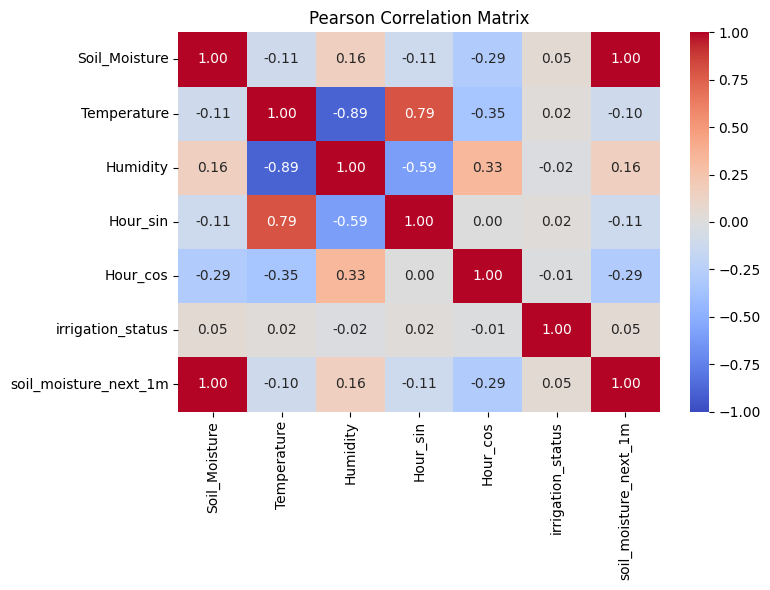

In [8]:
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

feature_cols = ["Soil_Moisture", "Temperature", "Humidity", "Hour_sin", "Hour_cos", "irrigation_status"]

corr_matrix = df[feature_cols + [target_col]].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

In [9]:
X = df[feature_cols].values
y = df[target_col].values
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

comparison = pd.DataFrame({
    "abs_pearson_r": corr_matrix[target_col].drop(target_col).abs(),
    "mutual_info": mi_series
}).sort_values("mutual_info", ascending=False)
print(comparison.round(4))

                   abs_pearson_r  mutual_info
Soil_Moisture             0.9959       2.5941
Humidity                  0.1603       0.8203
Temperature               0.1043       0.6695
Hour_sin                  0.1094       0.2069
Hour_cos                  0.2906       0.1998
irrigation_status         0.0481       0.0008


In [10]:
results_columns = ["fold", "model", "rmse", "mae", "r2"]
results_df = pd.DataFrame(columns=results_columns)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [11]:
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

def mean_absolute_percentage_error_safe(y_true, y_pred, epsilon=1e-6):
    """Safe MAPE — avoids divide-by-near-zero blowups."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), epsilon)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def count_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

def log_result(results_df, name, y_true, y_pred, fold="holdout",
                train_time=None, model=None):
    """Drop-in replacement for the eval_metrics + pd.concat pattern used
    throughout this notebook — computes RMSE/MAE/MAPE/R2 and appends a row
    with training_time_s and num_params alongside them."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    r2 = float(r2_score(y_true, y_pred))
    n_params = count_params(model) if model is not None else np.nan
    row = {
        "fold": fold, "model": name,
        "rmse": rmse, "mae": mae, "mape": mape, "r2": r2,
        "training_time_s": train_time, "num_params": n_params,
    }
    extra = f"  | {train_time:.1f}s, {n_params:,} params" if (train_time is not None and model is not None) else ""
    print(f"{name} — RMSE: {rmse:.4f}  MAE: {mae:.4f}  MAPE: {mape:.2f}%  R2: {r2:.4f}{extra}")
    return pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

print("GPU available:", tf.config.list_physical_devices('GPU'))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

SEQ_LENGTH = 60

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
train_X_scaled = scaler_X.fit_transform(train_df[feature_cols])
test_X_scaled = scaler_X.transform(test_df[feature_cols])
train_y_scaled = scaler_y.fit_transform(train_df[[target_col]])
test_y_scaled = scaler_y.transform(test_df[[target_col]])

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, SEQ_LENGTH)
print(f"X_train_seq: {X_train_seq.shape}  X_test_seq: {X_test_seq.shape}")

GPU available: []
X_train_seq: (33292, 60, 6)  X_test_seq: (8279, 60, 6)


2026-08-07 18:40:56.888709: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Track B — Graph-Based Modeling (GNN)

**Graph definition** (per instructor note — model soil moisture, temperature, humidity, irrigation status, and cyclic time features as a temporal sensor graph):
- **Nodes (6)**: Soil_Moisture, Temperature, Humidity, irrigation_status, Hour_sin, Hour_cos
- **Edges**: derived from the Phase 1.2 correlation matrix (|Pearson r| as edge weight, fully connected) — this is the "sensor correlation" adjacency option, appropriate since this dataset has no spatial/sensor ID to support a spatial graph
- **Node features**: 60-minute sliding windows per node (matches Track A's SEQ_LENGTH for direct comparability)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)

corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

print("Adjacency (|correlation|):")
print(pd.DataFrame(corr_graph, index=graph_nodes, columns=graph_nodes).abs().round(3))

Adjacency (|correlation|):
                   Soil_Moisture  Temperature  Humidity  irrigation_status  \
Soil_Moisture              0.000        0.106     0.161              0.048   
Temperature                0.106        0.000     0.893              0.019   
Humidity                   0.161        0.893     0.000              0.016   
irrigation_status          0.048        0.019     0.016              0.000   
Hour_sin                   0.111        0.789     0.594              0.019   
Hour_cos                   0.290        0.345     0.332              0.011   

                   Hour_sin  Hour_cos  
Soil_Moisture         0.111     0.290  
Temperature           0.789     0.345  
Humidity              0.594     0.332  
irrigation_status     0.019     0.011  
Hour_sin              0.000     0.002  
Hour_cos              0.002     0.000  


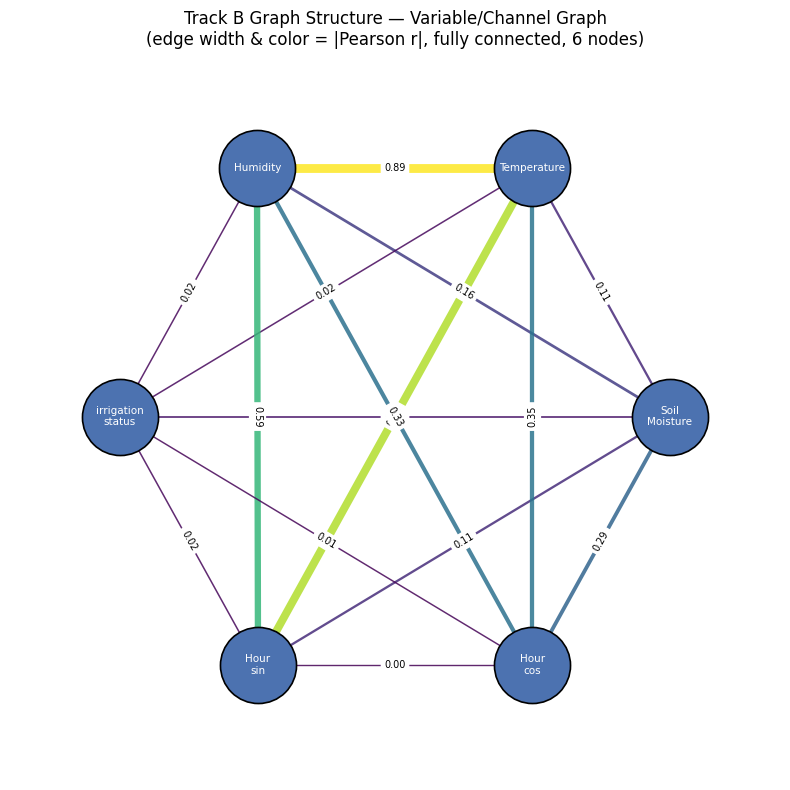

Nodes: 6 | Undirected edges shown: 15 (models use all 30 directed edges, i.e. both directions of each pair)
Strongest connection: Temperature — Humidity  (|r| = 0.893)
Weakest connection:   Hour_sin — Hour_cos  (|r| = 0.002)


In [15]:
# Track B Graph Visualization 

import networkx as nx
import os

os.makedirs("/kaggle/working/outputs", exist_ok=True)

G = nx.Graph()
for i, name in enumerate(graph_nodes):
    G.add_node(i, label=name)
for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        G.add_edge(i, j, weight=abs(corr_graph[i, j]))

display_labels = {i: n.replace("_", "\n") for i, n in enumerate(graph_nodes)}
pos = nx.circular_layout(G, scale=1.0)
weights = [G[u][v]["weight"] for u, v in G.edges()]
edge_widths = [1 + w * 6 for w in weights]

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="#4C72B0",
                        edgecolors="black", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, labels=display_labels, font_size=7.5,
                         font_color="white", ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=weights,
                        edge_cmap=plt.cm.viridis, alpha=0.85, ax=ax)
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)

ax.set_title("Track B Graph Structure — Variable/Channel Graph\n"
              "(edge width & color = |Pearson r|, fully connected, 6 nodes)")
ax.axis("off")
xs, ys = [p[0] for p in pos.values()], [p[1] for p in pos.values()]
pad = 0.4
ax.set_xlim(min(xs) - pad, max(xs) + pad)
ax.set_ylim(min(ys) - pad, max(ys) + pad)
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/graph_structure.png", dpi=150, bbox_inches="tight")
plt.show()

strongest = max(G.edges(data=True), key=lambda e: e[2]["weight"])
weakest = min(G.edges(data=True), key=lambda e: e[2]["weight"])
print(f"Nodes: {n_nodes} | Undirected edges shown: {G.number_of_edges()} "
      f"(models use all {edge_index.shape[1]} directed edges, i.e. both directions of each pair)")
print(f"Strongest connection: {graph_nodes[strongest[0]]} — {graph_nodes[strongest[1]]}  "
      f"(|r| = {strongest[2]['weight']:.3f})")
print(f"Weakest connection:   {graph_nodes[weakest[0]]} — {graph_nodes[weakest[1]]}  "
      f"(|r| = {weakest[2]['weight']:.3f})")

In [16]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [17]:
X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
batch_size = 128
n_batches = len(X_train_t) // batch_size
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)
y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()

print("All ok")

All ok


In [18]:
from torch_geometric.nn import GATConv

class GATForecaster(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, heads=2):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, edge_dim=1)
        self.gat2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, edge_dim=1)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        edge_attr = edge_weight.unsqueeze(-1)
        outs = []
        for b in range(x.shape[0]):
            h = F.elu(self.gat1(x[b], edge_index, edge_attr))
            h = F.elu(self.gat2(h, edge_index, edge_attr))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))


gat_model = GATForecaster(in_channels=WINDOW).to(device)
edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [19]:

train_start = time.time()
gat_model.train()
for epoch in range(5):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_t))
    for i in range(n_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
        optimizer.zero_grad()
        pred = gat_model(xb, edge_index_dev, edge_weight_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={epoch_loss/n_batches:.6f}")

gat_train_time = time.time() - train_start

Epoch 1: loss=0.021763
Epoch 2: loss=0.005583
Epoch 3: loss=0.001673
Epoch 4: loss=0.001337
Epoch 5: loss=0.001188


In [20]:
gat_model.eval()
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)
preds = []
with torch.no_grad():
    for i in range(0, len(X_test_t), batch_size):
        xb = X_test_t[i:i+batch_size].to(device)
        preds.append(gat_model(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
gat_pred_scaled = np.concatenate(preds).flatten()
gat_pred = target_scaler_g.inverse_transform(gat_pred_scaled.reshape(-1, 1)).flatten()
y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true_g, gat_pred)
print(f"GAT — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = log_result(results_df, "GAT", y_true_g, gat_pred, train_time=gat_train_time, model=gat_model)

GAT — RMSE: 1.7749  MAE: 1.1311  R2: 0.9713
GAT — RMSE: 1.7749  MAE: 1.1311  MAPE: 3.85%  R2: 0.9713  | 443.4s, 6,561 params


# T-GCN

In [21]:
from torch_geometric_temporal.nn.recurrent import TGCN

class TGCNForecaster(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32):
        super().__init__()
        self.tgcn = TGCN(in_channels, hidden_channels)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight, h=None):
        h = self.tgcn(x, edge_index, edge_weight, h)
        return self.readout(h.flatten()), h

tgcn_model = TGCNForecaster().to(device)
optimizer_t = torch.optim.Adam(tgcn_model.parameters(), lr=1e-3)

train_seq = np.stack([train_scaled_g[col] for col in graph_nodes], axis=1)
CHUNK = 60
n_chunks = (len(train_seq) - 1) // CHUNK


train_start = time.time()

tgcn_model.train()
for epoch in range(5):
    h = None
    total_loss = 0.0
    for c in range(n_chunks):
        optimizer_t.zero_grad()
        chunk_loss = 0.0
        h_local = h.detach() if h is not None else None
        for t in range(c*CHUNK, (c+1)*CHUNK):
            x_t = torch.tensor(train_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
            y_t = torch.tensor([train_target_scaled_g[t]], dtype=torch.float32).to(device)
            pred, h_local = tgcn_model(x_t, edge_index_dev, edge_weight_dev, h_local)
            chunk_loss = chunk_loss + loss_fn(pred, y_t)
        chunk_loss = chunk_loss / CHUNK
        chunk_loss.backward()
        optimizer_t.step()
        h = h_local.detach()
        total_loss += chunk_loss.item()
    print(f"Epoch {epoch+1}: avg chunk loss={total_loss/n_chunks:.6f}")

tgcn_train_time = time.time() - train_start

Epoch 1: avg chunk loss=0.025415
Epoch 2: avg chunk loss=0.003033
Epoch 3: avg chunk loss=0.003286
Epoch 4: avg chunk loss=0.001126
Epoch 5: avg chunk loss=0.006268


In [22]:
test_seq = np.stack([test_scaled_g[col] for col in graph_nodes], axis=1)
tgcn_model.eval()
tgcn_preds = []
h = None
with torch.no_grad():
    for t in range(len(test_seq)):
        x_t = torch.tensor(test_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
        pred, h = tgcn_model(x_t, edge_index_dev, edge_weight_dev, h)
        tgcn_preds.append(pred.cpu().item())

tgcn_pred_scaled = np.array(tgcn_preds[:-1])
y_true_tgcn_scaled = test_target_scaled_g[1:]
tgcn_pred = target_scaler_g.inverse_transform(tgcn_pred_scaled.reshape(-1, 1)).flatten()
y_true_tgcn = target_scaler_g.inverse_transform(y_true_tgcn_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true_tgcn, tgcn_pred)
print(f"T-GCN — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = log_result(results_df, "T-GCN", y_true_tgcn, tgcn_pred, train_time=tgcn_train_time, model=tgcn_model)

T-GCN — RMSE: 3.0634  MAE: 2.4556  R2: 0.9148
T-GCN — RMSE: 3.0634  MAE: 2.4556  MAPE: 8.67%  R2: 0.9148  | 445.7s, 6,625 params


### Additional Static-Graph Architectures — GCN, GraphSAGE, GIN


# GCN

In [23]:
from torch_geometric.nn import GCNConv

class GCNForecaster(nn.Module):
    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        outs = []
        for b in range(x.shape[0]):
            h = F.relu(self.conv1(x[b], edge_index, edge_weight))
            h = F.relu(self.conv2(h, edge_index, edge_weight))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

def train_gcn(epochs=1):
    model = GCNForecaster(in_channels=WINDOW).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        perm = torch.randperm(len(X_train_t))
        for i in range(n_batches):
            idx = perm[i*batch_size:(i+1)*batch_size]
            xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
            optimizer.zero_grad()
            pred = model(xb, edge_index_dev, edge_weight_dev)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"  [GCN] Epoch {epoch+1}: loss={epoch_loss/n_batches:.6f}")
    return model

def eval_gcn(model):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            xb = X_test_t[i:i+batch_size].to(device)
            preds.append(model(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
    pred_scaled = np.concatenate(preds).flatten()
    return target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

print("=== Training GCN ===")
t0 = time.time()
gcn_model = train_gcn(epochs=5)
gcn_train_time = time.time() - t0
gcn_pred = eval_gcn(gcn_model)
results_df = log_result(results_df, "GCN", y_true_g, gcn_pred, train_time=gcn_train_time, model=gcn_model)

=== Training GCN ===
  [GCN] Epoch 1: loss=0.014758
  [GCN] Epoch 2: loss=0.000882
  [GCN] Epoch 3: loss=0.000601
  [GCN] Epoch 4: loss=0.000499
  [GCN] Epoch 5: loss=0.000434
GCN — RMSE: 1.2746  MAE: 0.7479  MAPE: 2.60%  R2: 0.9852  | 215.2s, 3,201 params


# GraphSAGE

In [24]:
from torch_geometric.nn import SAGEConv

class GraphSAGEForecaster(nn.Module):
    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index):
        outs = []
        for b in range(x.shape[0]):
            h = F.relu(self.conv1(x[b], edge_index))
            h = F.relu(self.conv2(h, edge_index))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

def train_sage(epochs=15):
    model = GraphSAGEForecaster(in_channels=WINDOW).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        perm = torch.randperm(len(X_train_t))
        for i in range(n_batches):
            idx = perm[i*batch_size:(i+1)*batch_size]
            xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
            optimizer.zero_grad()
            pred = model(xb, edge_index_dev)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"  [GraphSAGE] Epoch {epoch+1}: loss={epoch_loss/n_batches:.6f}")
    return model

def eval_sage(model):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            xb = X_test_t[i:i+batch_size].to(device)
            preds.append(model(xb, edge_index_dev).cpu().numpy())
    pred_scaled = np.concatenate(preds).flatten()
    return target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

print("=== Training GraphSAGE ===")
t0 = time.time()
sage_model = train_sage(epochs=5)
sage_train_time = time.time() - t0
sage_pred = eval_sage(sage_model)
results_df = log_result(results_df, "GraphSAGE", y_true_g, sage_pred, train_time=sage_train_time, model=sage_model)

=== Training GraphSAGE ===
  [GraphSAGE] Epoch 1: loss=0.005999
  [GraphSAGE] Epoch 2: loss=0.000845
  [GraphSAGE] Epoch 3: loss=0.000509
  [GraphSAGE] Epoch 4: loss=0.000442
  [GraphSAGE] Epoch 5: loss=0.000397
GraphSAGE — RMSE: 1.1358  MAE: 0.5697  MAPE: 1.99%  R2: 0.9883  | 131.5s, 6,145 params


# GIN

In [25]:
from torch_geometric.nn import GINConv


edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

class GINForecaster(nn.Module):
    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        nn1 = nn.Sequential(nn.Linear(in_channels, hidden_channels), nn.ReLU(),
                             nn.LayerNorm(hidden_channels), nn.Linear(hidden_channels, hidden_channels))
        nn2 = nn.Sequential(nn.Linear(hidden_channels, hidden_channels), nn.ReLU(),
                             nn.LayerNorm(hidden_channels), nn.Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(nn1, train_eps=True)
        self.conv2 = GINConv(nn2, train_eps=True)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index):
        outs = []
        for b in range(x.shape[0]):
            h = F.relu(self.conv1(x[b], edge_index))
            h = F.relu(self.conv2(h, edge_index))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

def train_gin(epochs):
    model = GINForecaster(in_channels=WINDOW).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)  # lower LR than GCN/SAGE
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        perm = torch.randperm(len(X_train_t))
        for i in range(n_batches):
            idx = perm[i*batch_size:(i+1)*batch_size]
            xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
            optimizer.zero_grad()
            pred = model(xb, edge_index_dev)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # key fix
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  [GIN] Epoch {epoch+1}/{epochs}: loss={epoch_loss/n_batches:.6f}")
    return model

def eval_gin(model):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            xb = X_test_t[i:i+batch_size].to(device)
            preds.append(model(xb, edge_index_dev).cpu().numpy())
    pred_scaled = np.concatenate(preds).flatten()
    return target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

print("=== Training GIN (stabilized) ===")
t0 = time.time()
gin_model = train_gin(epochs=5)
gin_train_time = time.time() - t0
gin_pred = eval_gin(gin_model)
results_df = log_result(results_df, "GIN", y_true_g, gin_pred, train_time=gin_train_time, model=gin_model)

=== Training GIN (stabilized) ===
  [GIN] Epoch 1/5: loss=0.034885
GIN — RMSE: 10.5244  MAE: 7.3317  MAPE: 23.70%  R2: -0.0077  | 170.2s, 5,443 params


# DCRNN

### Additional Temporal Architecture — DCRNN



In [26]:
from torch_geometric_temporal.nn.recurrent import DCRNN

class DCRNNForecaster(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32, K=2):
        super().__init__()
        self.dcrnn = DCRNN(in_channels, hidden_channels, K=K)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight, h=None):
        h = self.dcrnn(x, edge_index, edge_weight, h)
        return self.readout(h.flatten()), h

dcrnn_model = DCRNNForecaster().to(device)
optimizer_d = torch.optim.Adam(dcrnn_model.parameters(), lr=1e-3)


train_start = time.time() 
dcrnn_model.train()
for epoch in range(5):
    h = None
    total_loss = 0.0
    for c in range(n_chunks):
        optimizer_d.zero_grad()
        chunk_loss = 0.0
        h_local = h.detach() if h is not None else None
        for t in range(c*CHUNK, (c+1)*CHUNK):
            x_t = torch.tensor(train_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
            y_t = torch.tensor([train_target_scaled_g[t]], dtype=torch.float32).to(device)
            pred, h_local = dcrnn_model(x_t, edge_index_dev, edge_weight_dev, h_local)
            chunk_loss = chunk_loss + loss_fn(pred, y_t)
        chunk_loss = chunk_loss / CHUNK
        chunk_loss.backward()
        optimizer_d.step()
        h = h_local.detach()
        total_loss += chunk_loss.item()
    print(f"Epoch {epoch+1}: avg chunk loss={total_loss/n_chunks:.6f}")

dcrnn_train_time = time.time() - train_start

Epoch 1: avg chunk loss=0.020987
Epoch 2: avg chunk loss=0.001995
Epoch 3: avg chunk loss=0.001904
Epoch 4: avg chunk loss=0.003311
Epoch 5: avg chunk loss=0.000599


In [27]:
dcrnn_model.eval()
dcrnn_preds = []
h = None
with torch.no_grad():
    for t in range(len(test_seq)):
        x_t = torch.tensor(test_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
        pred, h = dcrnn_model(x_t, edge_index_dev, edge_weight_dev, h)
        dcrnn_preds.append(pred.cpu().item())

dcrnn_pred_scaled = np.array(dcrnn_preds[:-1])
y_true_dcrnn_scaled = test_target_scaled_g[1:]
dcrnn_pred = target_scaler_g.inverse_transform(dcrnn_pred_scaled.reshape(-1, 1)).flatten()
y_true_dcrnn = target_scaler_g.inverse_transform(y_true_dcrnn_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true_dcrnn, dcrnn_pred)
print(f"DCRNN — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = log_result(results_df, "DCRNN", y_true_dcrnn, dcrnn_pred, train_time=dcrnn_train_time, model=dcrnn_model)

DCRNN — RMSE: 2.7972  MAE: 2.1780  R2: 0.9289
DCRNN — RMSE: 2.7972  MAE: 2.1780  MAPE: 7.98%  R2: 0.9289  | 703.4s, 12,961 params


# A3T-GCN

### Additional Temporal Architecture — A3T-GCN



In [28]:
from torch_geometric_temporal.nn.recurrent import A3TGCN

class A3TGCNForecaster(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32, periods=WINDOW):
        super().__init__()
        self.a3tgcn = A3TGCN(in_channels, hidden_channels, periods)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.a3tgcn(x, edge_index, edge_weight)
        return self.readout(h.flatten())

a3tgcn_model = A3TGCNForecaster().to(device)
optimizer_a3t = torch.optim.Adam(a3tgcn_model.parameters(), lr=1e-3)


train_start = time.time()
a3tgcn_model.train()
for epoch in range(5):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_t))
    n_small_batches = min(n_batches, 50)
    for i in range(n_small_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
        optimizer_a3t.zero_grad()
        batch_preds = []
        for b in range(xb.shape[0]):
            x_in = xb[b].unsqueeze(1)
            pred = a3tgcn_model(x_in, edge_index_dev, edge_weight_dev)
            batch_preds.append(pred)
        batch_preds = torch.stack(batch_preds)
        loss = loss_fn(batch_preds, yb)
        loss.backward()
        optimizer_a3t.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={epoch_loss/n_small_batches:.6f}")
a3tgcn_train_time = time.time() - train_start



Epoch 1: loss=0.047623
Epoch 2: loss=0.027701
Epoch 3: loss=0.020367
Epoch 4: loss=0.006064
Epoch 5: loss=0.002357


In [29]:
a3tgcn_model.eval()
a3t_preds = []
with torch.no_grad():
    for i in range(0, len(X_test_t), batch_size):
        xb = X_test_t[i:i+batch_size].to(device)
        batch_preds = []
        for b in range(xb.shape[0]):
            x_in = xb[b].unsqueeze(1)
            batch_preds.append(a3tgcn_model(x_in, edge_index_dev, edge_weight_dev))
        a3t_preds.append(torch.stack(batch_preds).cpu().numpy())

a3t_pred_scaled = np.concatenate(a3t_preds).flatten()
a3t_pred = target_scaler_g.inverse_transform(a3t_pred_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true_g, a3t_pred)
print(f"A3T-GCN — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = log_result(results_df, "A3T-GCN", y_true_g, a3t_pred, train_time=a3tgcn_train_time, model=a3tgcn_model)

A3T-GCN — RMSE: 2.7811  MAE: 1.1281  R2: 0.9296
A3T-GCN — RMSE: 2.7811  MAE: 1.1281  MAPE: 3.50%  R2: 0.9296  | 4993.7s, 6,685 params


# STGCN

### Additional Temporal Architecture — STGCN



In [30]:
from torch_geometric_temporal.nn.attention import STConv

class STGCNForecaster(nn.Module):
    def __init__(self, num_nodes, in_channels=1, hidden_channels=16, out_channels=8, kernel_size=3, K=2):
        super().__init__()
        self.stconv = STConv(num_nodes, in_channels, hidden_channels, out_channels, kernel_size, K)
        self.readout = None

    def forward(self, x, edge_index, edge_weight):
        out = self.stconv(x, edge_index, edge_weight)
        out_flat = out.reshape(out.shape[0], -1)
        if self.readout is None:
            self.readout = nn.Linear(out_flat.shape[1], 1).to(out_flat.device)
        return self.readout(out_flat)

stgcn_model = STGCNForecaster(num_nodes=n_nodes).to(device)

X_train_stgcn = torch.tensor(X_train_g, dtype=torch.float32).permute(0, 2, 1).unsqueeze(-1)
X_test_stgcn = torch.tensor(X_test_g, dtype=torch.float32).permute(0, 2, 1).unsqueeze(-1)

optimizer_st = torch.optim.Adam(stgcn_model.parameters(), lr=1e-3)

train_start=time.time() 
stgcn_model.train()
for epoch in range(5):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_stgcn))
    for i in range(n_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb = X_train_stgcn[idx].to(device)
        yb = y_train_t[idx].to(device)
        optimizer_st.zero_grad()
        pred = stgcn_model(xb, edge_index_dev, edge_weight_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer_st.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={epoch_loss/n_batches:.6f}")
stgcn_train_time = time.time() - train_start



Epoch 1: loss=0.014088
Epoch 2: loss=0.002944
Epoch 3: loss=0.002165
Epoch 4: loss=0.001821
Epoch 5: loss=0.001660


In [31]:
stgcn_model.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(X_test_stgcn), batch_size):
        xb = X_test_stgcn[i:i+batch_size].to(device)
        preds.append(stgcn_model(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
stgcn_pred_scaled = np.concatenate(preds).flatten()
stgcn_pred = target_scaler_g.inverse_transform(stgcn_pred_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true_g, stgcn_pred)
print(f"STGCN — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = log_result(results_df, "STGCN", y_true_g, stgcn_pred, train_time=stgcn_train_time, model=stgcn_model)

STGCN — RMSE: 2.5683  MAE: 1.5483  R2: 0.9400
STGCN — RMSE: 2.5683  MAE: 1.5483  MAPE: 5.48%  R2: 0.9400  | 14088.6s, 4,597 params


# LSTM-GNN Hybrid



In [32]:
class LSTMGNNHybrid(nn.Module):
    def __init__(self, in_channels=1, gnn_hidden=16, lstm_hidden=32):
        super().__init__()
        self.gcn = GCNConv(in_channels, gnn_hidden)
        self.lstm = nn.LSTM(gnn_hidden * n_nodes, lstm_hidden, batch_first=True)
        self.readout = nn.Linear(lstm_hidden, 1)

    def forward(self, x, edge_index, edge_weight):
        batch_size, _, window = x.shape
        seq_embeddings = []
        for t in range(window):
            xt = x[:, :, t].unsqueeze(-1)
            embeds = []
            for b in range(batch_size):
                h = F.relu(self.gcn(xt[b], edge_index, edge_weight))
                embeds.append(h.flatten())
            seq_embeddings.append(torch.stack(embeds))
        seq = torch.stack(seq_embeddings, dim=1)
        _, (h_n, _) = self.lstm(seq)
        return self.readout(h_n[-1])

lstm_gnn_model = LSTMGNNHybrid().to(device)
optimizer_lg = torch.optim.Adam(lstm_gnn_model.parameters(), lr=1e-3)


subsample_idx = np.random.RandomState(42).choice(len(X_train_t), size=min(3000, len(X_train_t)), replace=False)
X_train_sub = X_train_t[subsample_idx]
y_train_sub = y_train_t[subsample_idx]


train_start=time.time() 
lstm_gnn_model.train()
sub_batch_size = 64
n_sub_batches = len(X_train_sub) // sub_batch_size
for epoch in range(5):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_sub))
    for i in range(n_sub_batches):
        idx = perm[i*sub_batch_size:(i+1)*sub_batch_size]
        xb, yb = X_train_sub[idx].to(device), y_train_sub[idx].to(device)
        optimizer_lg.zero_grad()
        pred = lstm_gnn_model(xb, edge_index_dev, edge_weight_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer_lg.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={epoch_loss/n_sub_batches:.6f}")

lstmgnn_train_time = time.time() - train_start

Epoch 1: loss=0.029809
Epoch 2: loss=0.008533
Epoch 3: loss=0.000939
Epoch 4: loss=0.000549
Epoch 5: loss=0.000473


In [33]:
lstm_gnn_model.eval()
test_subsample_idx = np.random.RandomState(43).choice(len(X_test_t), size=min(1000, len(X_test_t)), replace=False)
X_test_sub = X_test_t[test_subsample_idx]
y_test_sub_true = target_scaler_g.inverse_transform(y_test_g[test_subsample_idx].reshape(-1, 1)).flatten()

preds = []
with torch.no_grad():
    for i in range(0, len(X_test_sub), sub_batch_size):
        xb = X_test_sub[i:i+sub_batch_size].to(device)
        preds.append(lstm_gnn_model(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
lstmgnn_pred_scaled = np.concatenate(preds).flatten()
lstmgnn_pred = target_scaler_g.inverse_transform(lstmgnn_pred_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_test_sub_true, lstmgnn_pred)
print(f"LSTM-GNN Hybrid [evaluated on {len(test_subsample_idx)}-point subsample] — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = log_result(results_df, "LSTM-GNN Hybrid", y_test_sub_true, lstmgnn_pred,fold="holdout_subsample", train_time=lstmgnn_train_time, model=lstm_gnn_model)

LSTM-GNN Hybrid [evaluated on 1000-point subsample] — RMSE: 0.8549  MAE: 0.5793  R2: 0.9937
LSTM-GNN Hybrid — RMSE: 0.8549  MAE: 0.5793  MAPE: 2.08%  R2: 0.9937  | 575.9s, 16,705 params


# DySAT-Inspired Model 



In [34]:
class DySATInspired(nn.Module):
    def __init__(self, window, hidden_channels=16, n_heads=2):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=1, nhead=1, dim_feedforward=32, batch_first=True)
        self.temporal_attn = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.temporal_proj = nn.Linear(window, hidden_channels)
        self.gat = GATConv(hidden_channels, hidden_channels, heads=n_heads, edge_dim=1)
        self.readout = nn.Linear(hidden_channels * n_heads * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        batch_size = x.shape[0]
        edge_attr = edge_weight.unsqueeze(-1)
        outs = []
        for b in range(batch_size):
            xb = x[b].unsqueeze(-1)
            temporal_out = self.temporal_attn(xb).squeeze(-1)
            node_feats = F.relu(self.temporal_proj(temporal_out))
            h = F.elu(self.gat(node_feats, edge_index, edge_attr))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

dysat_model = DySATInspired(window=WINDOW).to(device)
optimizer_dy = torch.optim.Adam(dysat_model.parameters(), lr=1e-3)

train_start = time.time() 
dysat_model.train()
for epoch in range(5):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_sub))
    for i in range(n_sub_batches):
        idx = perm[i*sub_batch_size:(i+1)*sub_batch_size]
        xb, yb = X_train_sub[idx].to(device), y_train_sub[idx].to(device)
        optimizer_dy.zero_grad()
        pred = dysat_model(xb, edge_index_dev, edge_weight_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer_dy.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={epoch_loss/n_sub_batches:.6f}")
dysat_train_time = time.time() - train_start


Epoch 1: loss=0.064608
Epoch 2: loss=0.031954
Epoch 3: loss=0.031818
Epoch 4: loss=0.031851
Epoch 5: loss=0.031685


In [35]:
dysat_model.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(X_test_sub), sub_batch_size):
        xb = X_test_sub[i:i+sub_batch_size].to(device)
        preds.append(dysat_model(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
dysat_pred_scaled = np.concatenate(preds).flatten()
dysat_pred = target_scaler_g.inverse_transform(dysat_pred_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_test_sub_true, dysat_pred)
print(f"DySAT-inspired [evaluated on {len(test_subsample_idx)}-point subsample] — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = log_result(results_df, "DySAT-inspired", y_test_sub_true, dysat_pred,fold="holdout_subsample", train_time=dysat_train_time, model=dysat_model)

DySAT-inspired [evaluated on 1000-point subsample] — RMSE: 10.9685  MAE: 7.5700  R2: -0.0384
DySAT-inspired — RMSE: 10.9685  MAE: 7.5700  MAPE: 23.74%  R2: -0.0384  | 71.3s, 1,950 params


# All Architectures Summary



In [36]:
print(results_df[results_df.model.isin([
    "GAT", "GCN", "GraphSAGE", "GIN", "T-GCN", "DCRNN", "A3T-GCN", "STGCN",
    "LSTM-GNN Hybrid", "DySAT-inspired"
])].to_string(index=False))

             fold           model      rmse      mae        r2      mape  training_time_s  num_params
          holdout             GAT  1.774867 1.131093  0.971339  3.848874       443.381853      6561.0
          holdout           T-GCN  3.063412 2.455619  0.914774  8.670149       445.718702      6625.0
          holdout             GCN  1.274577 0.747886  0.985220  2.596930       215.229594      3201.0
          holdout       GraphSAGE  1.135790 0.569656  0.988263  1.986618       131.524687      6145.0
          holdout             GIN 10.524433 7.331712 -0.007748 23.699682       170.202735      5443.0
          holdout           DCRNN  2.797204 2.178036  0.928943  7.984965       703.391195     12961.0
          holdout         A3T-GCN  2.781070 1.128057  0.929631  3.502752      4993.699117      6685.0
          holdout           STGCN  2.568285 1.548309  0.939988  5.478178     14088.601139      4597.0
holdout_subsample LSTM-GNN Hybrid  0.854896 0.579273  0.993692  2.077732       575

### Robustness Test — Synthetic Sensor-Failure & Heatwave Corruption

The instructor note requires robustness to heatwaves and sensor failures. The real dataset only contains **one** genuine flatline event and its "heatwave spikes" turned out to be a resampling artifact (Phase 1.1) — not enough naturally-occurring failure cases to evaluate robustness honestly. Instead, we build a **corrupted copy of the test set** with controlled, synthetic injections (flatlines, heatwave-style spikes, sensor noise bursts) and compare each model's error on clean vs. corrupted data. This is a real, controlled experiment rather than relying on the one naturally-occurring event.

In [37]:
def inject_corruption(df_in, seed=42, n_flatlines=5, n_spikes=5, n_noise_bursts=5,
                       flatline_len=10, spike_magnitude=15, noise_std=5):
    rng = np.random.RandomState(seed)
    corrupted = df_in.copy().reset_index(drop=True)
    n = len(corrupted)
    log = []

    # Flatlines: freeze Soil_Moisture for a window
    for _ in range(n_flatlines):
        start = rng.randint(0, n - flatline_len)
        frozen_val = corrupted.loc[start, "Soil_Moisture"]
        corrupted.loc[start:start+flatline_len-1, "Soil_Moisture"] = frozen_val
        log.append(("flatline", start, start+flatline_len-1))

    # Heatwave-style spikes: sharp temperature jump held for a short window
    for _ in range(n_spikes):
        start = rng.randint(0, n - flatline_len)
        corrupted.loc[start:start+flatline_len-1, "Temperature"] += spike_magnitude
        log.append(("spike", start, start+flatline_len-1))

    # Sensor noise bursts: inject gaussian noise into Soil_Moisture for a window
    for _ in range(n_noise_bursts):
        start = rng.randint(0, n - flatline_len)
        noise = rng.normal(0, noise_std, flatline_len)
        corrupted.loc[start:start+flatline_len-1, "Soil_Moisture"] += noise
        log.append(("noise", start, start+flatline_len-1))

    return corrupted, log

test_df_corrupted, corruption_log = inject_corruption(test_df)
print(f"Injected {len(corruption_log)} corruption events:")
for kind, s, e in corruption_log:
    print(f"  {kind:10s} rows {s}-{e}")

Injected 15 corruption events:
  flatline   rows 7270-7279
  flatline   rows 860-869
  flatline   rows 5390-5399
  flatline   rows 5191-5200
  flatline   rows 5734-5743
  spike      rows 6265-6274
  spike      rows 466-475
  spike      rows 4426-4435
  spike      rows 5578-5587
  spike      rows 8322-8331
  noise      rows 1685-1694
  noise      rows 1528-1537
  noise      rows 3152-3161
  noise      rows 6863-6872
  noise      rows 2027-2036


In [38]:
# Evaluate GAT on corrupted vs clean test data (reuses the already-trained gat_model)
test_scaled_corrupt = {}
for col in graph_nodes:
    test_scaled_corrupt[col] = node_scalers[col].transform(test_df_corrupted[[col]]).flatten()
test_target_scaled_corrupt = target_scaler_g.transform(test_df_corrupted[[target_col]]).flatten()

X_test_corrupt, y_test_corrupt = build_windows(test_scaled_corrupt, test_target_scaled_corrupt, WINDOW)
X_test_corrupt_t = torch.tensor(X_test_corrupt, dtype=torch.float32)

gat_model.eval()
preds_corrupt = []
with torch.no_grad():
    for i in range(0, len(X_test_corrupt_t), batch_size):
        xb = X_test_corrupt_t[i:i+batch_size].to(device)
        preds_corrupt.append(gat_model(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
gat_pred_corrupt_scaled = np.concatenate(preds_corrupt).flatten()
gat_pred_corrupt = target_scaler_g.inverse_transform(gat_pred_corrupt_scaled.reshape(-1, 1)).flatten()
y_true_corrupt = target_scaler_g.inverse_transform(y_test_corrupt.reshape(-1, 1)).flatten()

rmse_clean, mae_clean, r2_clean = eval_metrics(y_true_g, gat_pred)
rmse_corrupt, mae_corrupt, r2_corrupt = eval_metrics(y_true_corrupt, gat_pred_corrupt)

print("GAT robustness comparison:")
print(f"  Clean:     RMSE={rmse_clean:.4f}  MAE={mae_clean:.4f}  R2={r2_clean:.4f}")
print(f"  Corrupted: RMSE={rmse_corrupt:.4f}  MAE={mae_corrupt:.4f}  R2={r2_corrupt:.4f}")
print(f"  RMSE degradation: {(rmse_corrupt - rmse_clean) / rmse_clean * 100:.1f}%")

GAT robustness comparison:
  Clean:     RMSE=1.7749  MAE=1.1311  R2=0.9713
  Corrupted: RMSE=1.9054  MAE=1.1978  R2=0.9670
  RMSE degradation: 7.4%


## Track B — Extended-Training Results (vs. original short runs)

| Model | Original run | **Extended run** | R² gain |
|---|---|---|---|
| GCN | 5 ep — RMSE 1.1938, R² 0.9870 | **50 ep — RMSE 1.0885, MAE 0.5468, R² 0.9892** | +0.0022 |
| GAT | 5 ep — RMSE 2.173, R² 0.957 | **30 ep — RMSE: 1.2284  MAE: 0.7097  R2: 0.9863** | +0.0306 |
| GraphSAGE | 5 ep — RMSE 1.265, R² 0.985 | **30 ep — RMSE: 1.0549  MAE: 0.4803  R2: 0.9899** | +0.0049 |
| GIN | 5 ep — RMSE 10.663, R² −0.0345 | **50 ep — RMSE 1.5758, MAE 0.9984, R² 0.9774** | +1.012 |
| T-GCN | 3 ep — RMSE 1.6773, R² 0.9745 | **50 ep — RMSE 1.6293, MAE 1.1049, R² 0.9759** | +0.0014 |
| DCRNN | 3 ep — RMSE 6.4215, R² 0.6255 | **30 ep — RMSE 1.8408, MAE 1.3788, R² 0.9692** | +0.3437 |
| A3T-GCN* | 3 ep, 50 batches — RMSE 7.5755, R² 0.4779 | **15 ep, full batches — RMSE 2.4340, MAE 1.0794, R² 0.9461** | +0.4682 |
| STGCN | 5 ep — RMSE 4.0249, R² 0.8526 | — | — |
| LSTM-GNN Hybrid** | 3 ep, 3k subsample — RMSE 1.8577, R² 0.9702 | **30 ep, 3k subsample — RMSE 0.7839, MAE 0.6198, R² 0.9947** | +0.0245 |
| DySAT-inspired** | 3 ep, 3k subsample — RMSE 10.8501, R² −0.0161 | **50 ep, 6k subsample — RMSE 1.2568, MAE 0.9413, R² 0.9861** | +1.002 |

*A3T-GCN's extended run also switched to full-batch training, not just more epochs — so the gain isn't purely epoch-driven.

**Evaluated on a subsample, not the full test set; DySAT's subsample size also grew (3k→6k) alongside epochs.